# Project : Spotify audio features EDA & Visualization
- 프로젝트 목적 : 스포티파이 음악 데이터를 바탕으로 EDA 및 시각화
- 데이터 정보
    - 규모 : 50000 rows * 21 columns
    - 기간 : 2000년 ~ 2024년
    - 출처 : [(Kaggle) Spotify audio features Dataset](https://www.kaggle.com/datasets/lorenzoscaturchio/spotify-tracks-audio-features-50k)
- 최종 수정 : 2026-06-29

## 라이브러리 및 데이터 로드

In [2]:
# 데이터 처리
import numpy as np
import pandas as pd

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
# 시각화 기본 세팅
sns.set_theme(style="whitegrid")

## 한글 깨짐 방지
## 윈도우
# plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['axes.unicode_minus'] = False
# 맥
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 그 외
# 경고 무시
import warnings
warnings.filterwarnings("ignore")

# 시스템
import os
import gc

In [3]:
PATH = '/Users/hyun/Documents/project/spotify-audio-features-analysis/data/raw/'

df = pd.read_csv(f"{PATH}spotify_tracks.csv")
print(df.shape)
df.head()

(50000, 21)


,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [4]:
print(df.info(memory_usage='deep'), '\n')
print(df.isnull().sum(), '\n')
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  str    
 1   track_name        50000 non-null  str    
 2   artist_name       50000 non-null  str    
 3   album_name        50000 non-null  str    
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  str    
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float64
 17  temp

,release_year,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2015.853400,23.599560,209976.955080,0.626921,0.658879,-7.438755,0.076370,0.275942,0.155218,0.181120,0.581443,116.258270,5.477220,0.619900,4.042800
std,6.178209,17.912623,44881.858907,0.207513,0.212950,4.305645,0.064989,0.257911,0.235443,0.096788,0.183994,23.706129,3.598764,0.485416,0.513939
min,2000.000000,-5.000000,90000.000000,0.000000,0.000000,-27.795904,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,3.000000
25%,2012.000000,11.000000,179812.250000,0.489439,0.539592,-9.802727,0.031339,0.075444,0.000000,0.112240,0.457651,100.238179,2.000000,0.000000,4.000000
50%,2017.000000,19.000000,209886.500000,0.651486,0.683479,-6.906656,0.062609,0.198993,0.064522,0.179683,0.581160,115.325911,5.000000,1.000000,4.000000
75%,2021.000000,31.000000,240023.750000,0.783254,0.812390,-4.425697,0.098898,0.412742,0.168282,0.247669,0.708097,130.455924,9.000000,1.000000,4.000000
max,2024.000000,100.000000,403583.000000,1.000000,1.000000,0.000000,0.368468,1.000000,1.000000,0.581942,1.000000,220.000000,11.000000,1.000000,7.000000


In [5]:
# duration 파생변수 생성
df['duration_min'] = round(df['duration_ms'] / 60000, 2)

print(df['duration_min'].head())

0    3.15
1    3.11
2    2.03
3    3.60
4    2.60
Name: duration_min, dtype: float64


**칼럼 특성 정리**

- Numeric
    - 연속형 : 'popularity', 'duration_ms',
                'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo'
    - 숫자형 : 'release_year', 'key', 'mode', 'time_signature'

- Object
    - 'track_id', 'track_name', 'artist_name', 'album_name', 'genre', 'explicit'

> **핵심 col : 'popularity'**
- audio features : 'danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'

## 가설 설정 (핵심 질문)

1. popularity 는 음악의 특성(feature)와 유의미한 상관관계를 보일것이다.

2. 음악의 특성들을 바탕으로 음악의 컨셉(?) 과 같은 군집화가 가능할것이다.

3. release_year, popularity, genre 칼럼을 바탕으로 연도별 음악의 유행 트렌드(feature별 특정 범위 등)가 유의미하게 구분될 것이다.

## 기초 EDA

### 단변량 분석

In [ ]:
# 연속형 변수
numeric_cols = ['popularity', 'duration_min',
                'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                'instrumentalness', 'liveness', 'valence', 'tempo']

# 이산형 변수
discrete_cols = ['release_year', 'key', 'mode', 'time_signature']

# 범주형 변수
object_cols = ['track_id', 'track_name', 'artist_name', 'album_name', 'genre', 'explicit']

# 빠뜨린 칼럼 있는지 확인
print(len(numeric_cols) + len(discrete_cols) + len(object_cols))

21


#### 연속형 변수

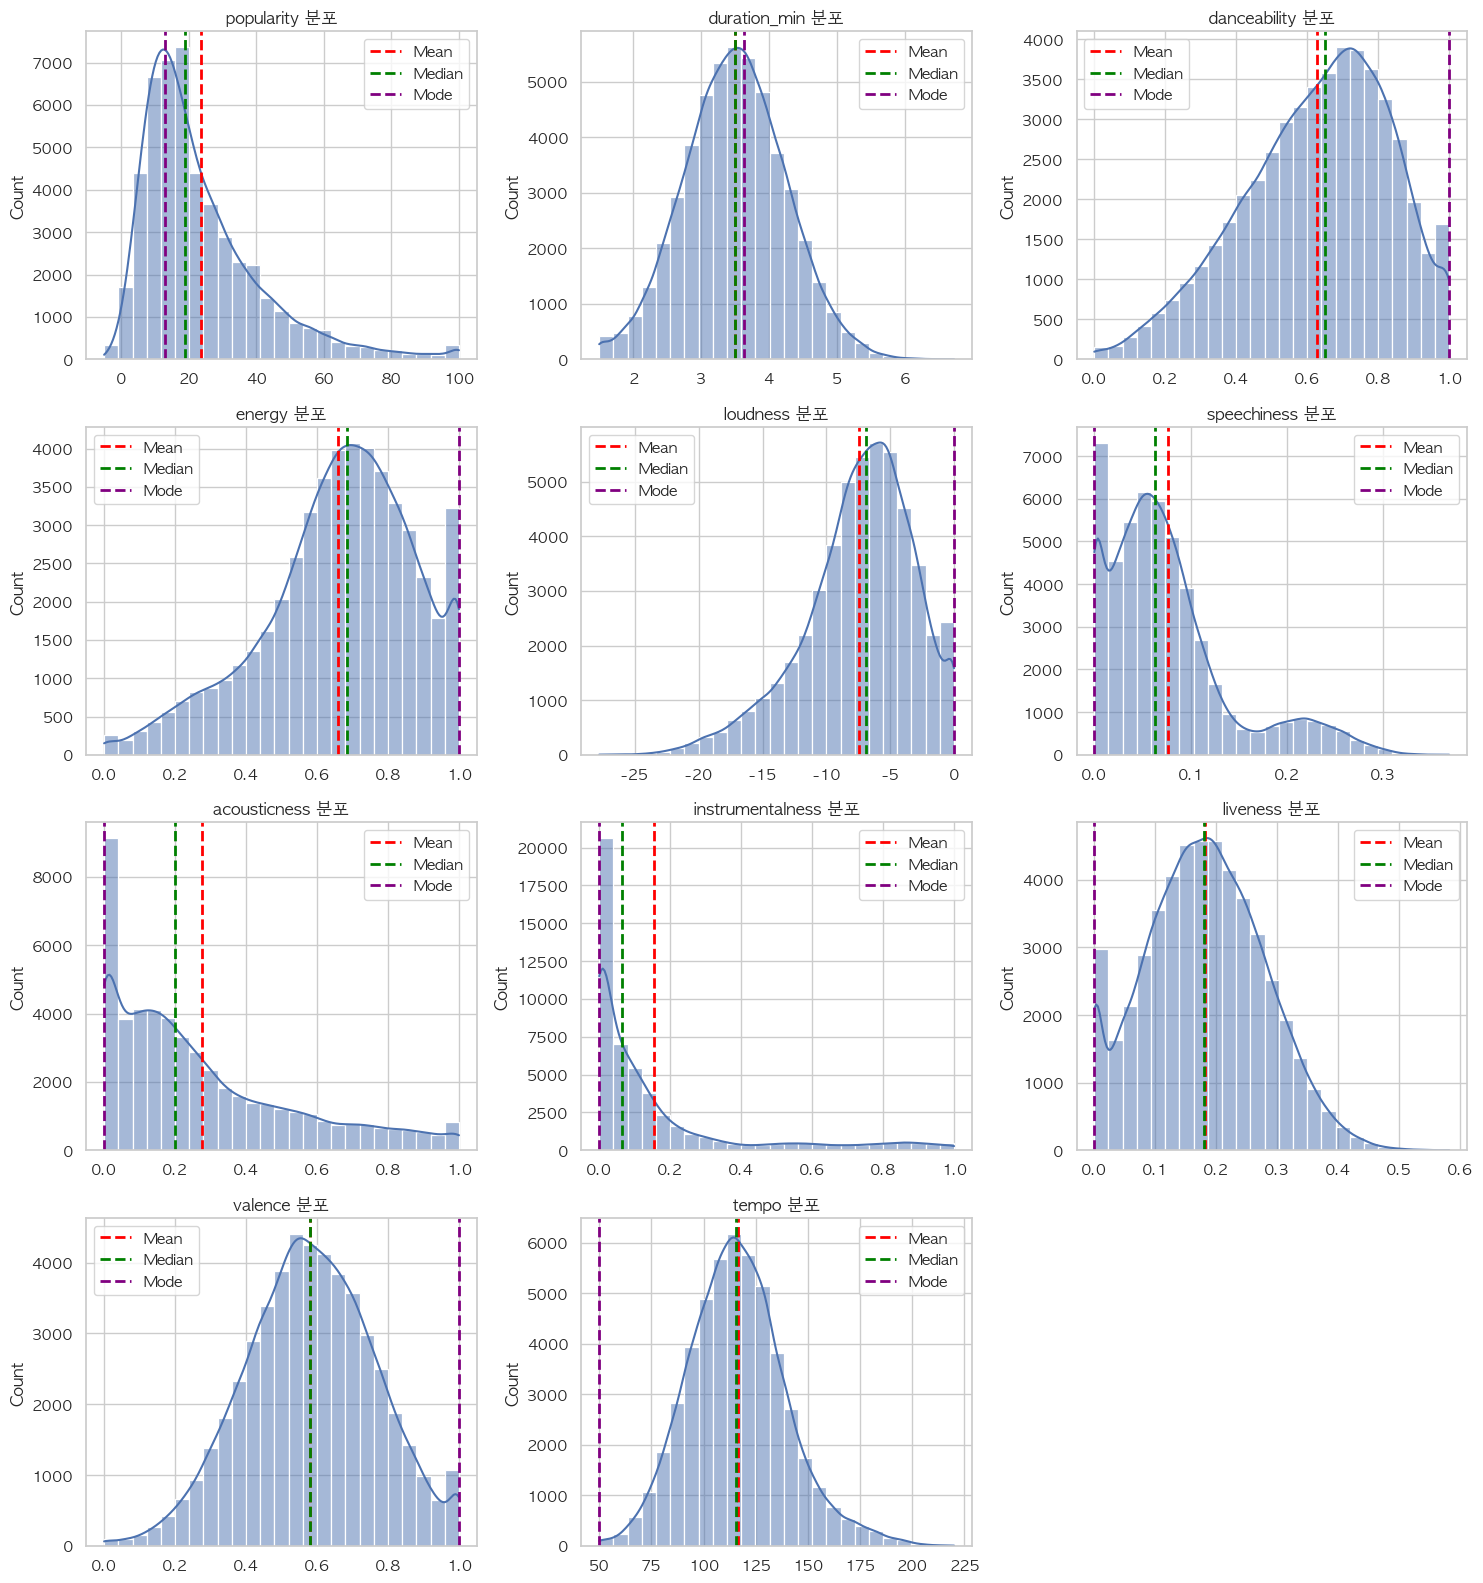

In [7]:
import math

n_cols = 3
n_rows = math.ceil(
    len(numeric_cols) / n_cols
)

fig, axes = plt.subplots(
    nrows=n_rows, ncols=n_cols, figsize=(n_cols * 5, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=25, ax=ax)
    ax.set_title(f'{col} 분포')
    ax.set_xlabel('')   # X축 이름은 타이틀과 겹치니까 빈칸으로

    # 보조 지표
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = (
        df[col].mode()[0] if not df[col].mode().empty else mean_val
    )  # 최빈값이 없을 경우 대비

    # mean (평균) - 빨
    ax.axvline(
        mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean'
    )
    # median (중앙값) - 초
    ax.axvline(
        median_val,
        color='green', linestyle='--', linewidth=2, label=f'Median'
    )
    # mode (최빈값) - 보
    ax.axvline(
        mode_val, color='purple', linestyle='--', linewidth=2, label=f'Mode'
    )

    ax.legend()

# 빈 서브플롯 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 이산형 변수

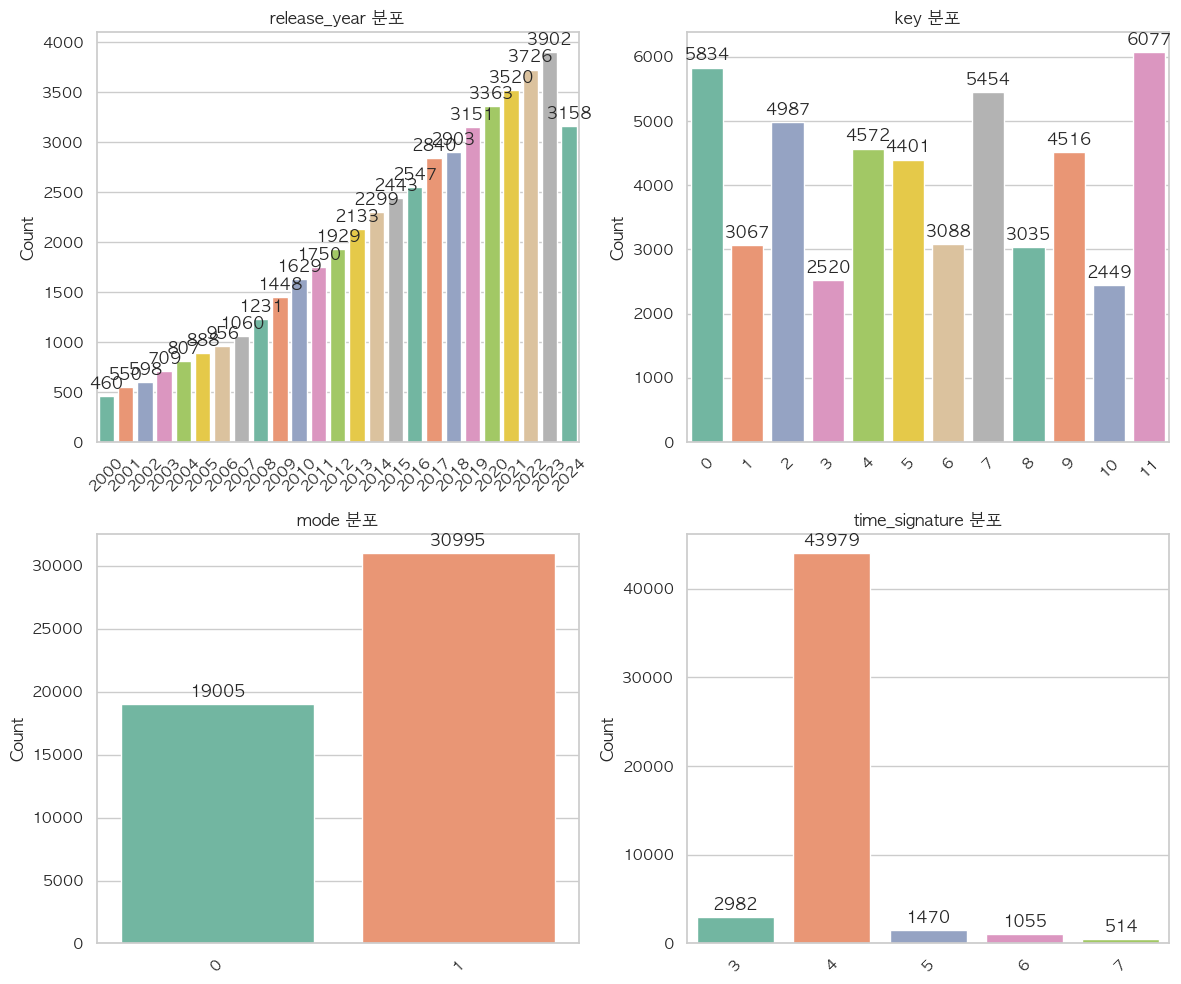

In [8]:
n_rows = 2
n_cols = 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 10))

axes = axes.flatten()

for i, col in enumerate(discrete_cols):
    ax = axes[i]

    sns.countplot(data=df, x=col, ax=ax, palette='Set2')

    for container in ax.containers:
        ax.bar_label(container, fmt="%d", label_type="edge", padding=3)

    ax.set_title(f'{col} 분포', fontsize=12)
    ax.set_xlabel('')  # X축 이름은 타이틀과 겹치니까 빈칸으로
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

#### 범주형 변수

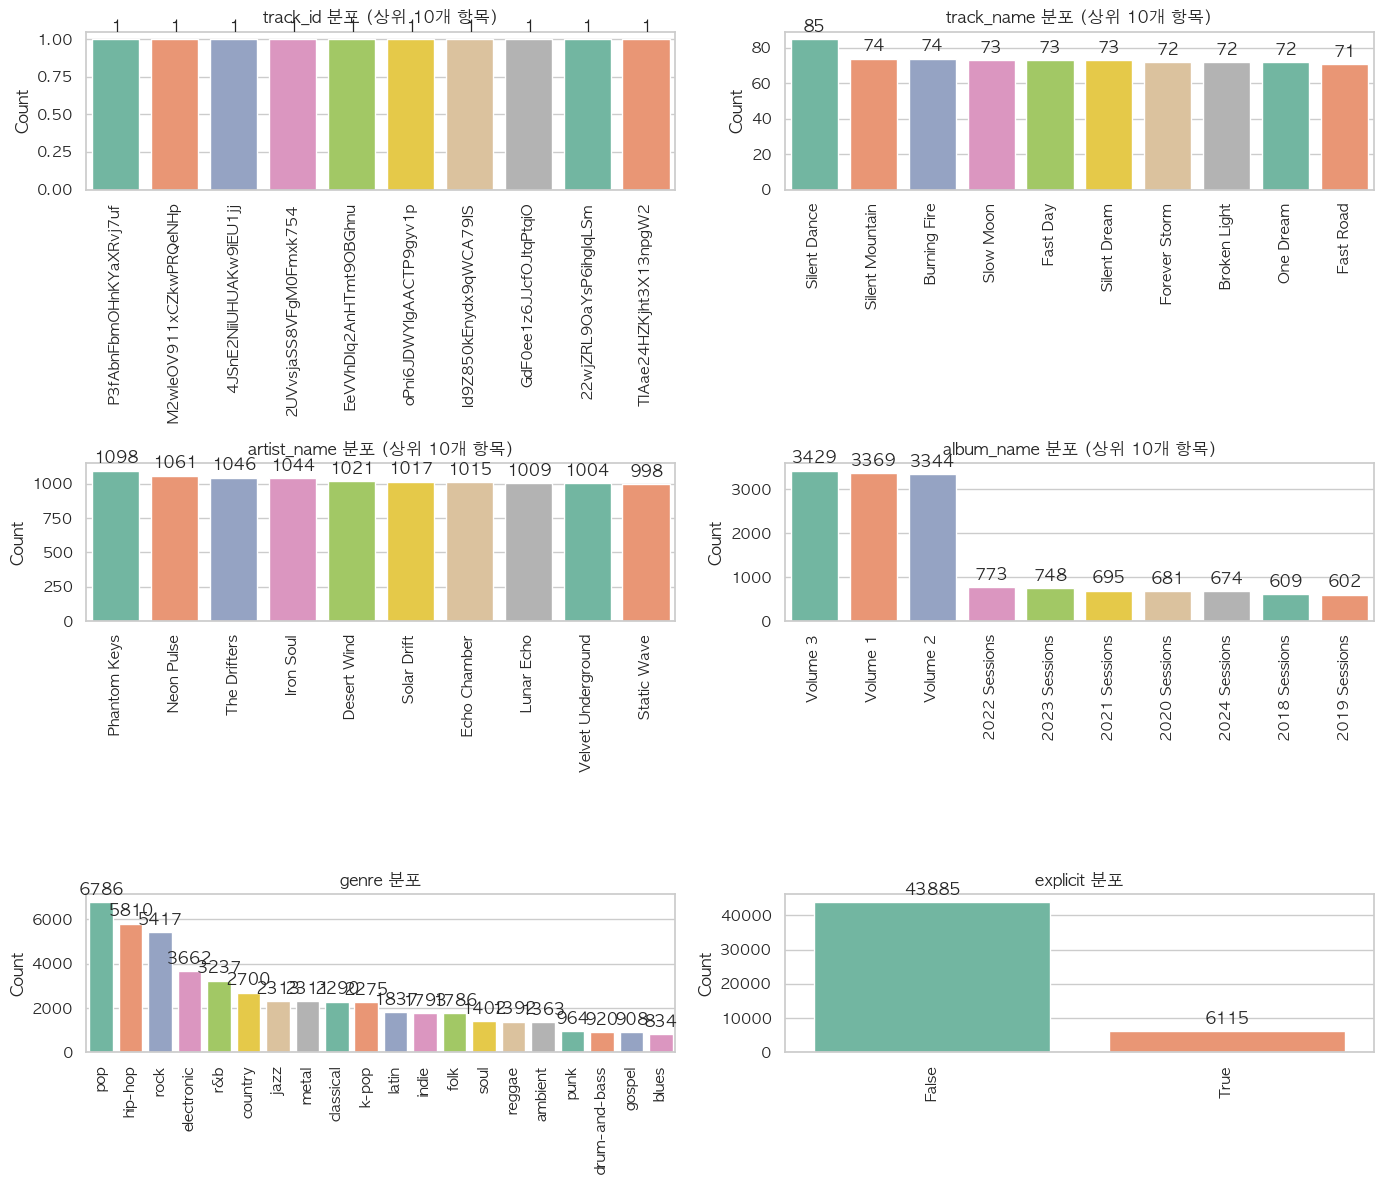

In [ ]:
n_rows = 3
n_cols = 2
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, 12))

axes = axes.flatten()

for i, col in enumerate(object_cols):
    ax = axes[i]

    # 💡 안전장치 : 고유값이 너무 많으면 상위 N개만 집계
    if df[col].nunique() > 30:
        top_categories = df[col].value_counts().head(10).index
        plot_data = df[df[col].isin(top_categories)]
        order_list = top_categories
        ax.set_title(f'{col} 분포 (상위 10개 항목)', fontsize=12)
    else:
        plot_data = df
        order_list = df[col].value_counts().index  # 빈도순 정렬
        ax.set_title(f'{col} 분포', fontsize=12)

    # countplot 그리기 (order 옵션을 주면 빈도순으로 예쁘게 정렬됩니다)
    sns.countplot(data=plot_data, x=col, ax=ax, palette='Set2', order=order_list)

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', labelrotation=90)

plt.tight_layout()
plt.show()

# 다음 진행 예정

# Part 1. 가설 1 검증 (popularity vs 오디오 피처)
1. 전체 수치형 변수 간의 Pearson 상관계수 matrix 계산 및 sns.heatmap() 시각화
2. popularity 상위 N% 그룹 vs 나머지 그룹 분할
3. 두 그룹 간의 주요 피처(danceability, energy 등) 평균 차이를 시각화(Boxplot)하고 t-test로 통계적 유의성(p-value) 검정

# Part 2. 가설 3 검증 (연도별/장르별 트렌드 시계열)
1. df.groupby('release_year')[['danceability', 'energy', 'loudness']].mean() 계산
2. 시간에 따른 음악적 특성 변화 추이를 sns.lineplot()으로 시각화
3. 상위 3개 주류 장르를 필터링하여, 연도별 대중성(popularity) 추이 교차 비교

# Part 3. 가설 2 검증 빌드업 (군집화 타당성)
1. 가장 대중성과 연관 깊거나 분산이 큰 두 변수(예: valence vs energy)를 선택
2. 상위 3대 장르별로 색상(hue)을 다르게 하여 sns.scatterplot() 생성 후, 공간상 군집 경향성 육안 확인